## Setup environment

In [1]:
!python -c "import monai" || pip install -q "monai-weekly[tqdm, nibabel]"
%matplotlib inline

Traceback (most recent call last):
  File "<string>", line 1, in <module>
ModuleNotFoundError: No module named 'monai'
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 8.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 75.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 86.0 MB/s eta 0:00:00


## Setup imports

In [2]:
import os
import tempfile
from glob import glob
import shutil
import matplotlib.pyplot as plt
import monai
import nibabel as nib
import numpy as np
import torch
from monai.data import DataLoader, create_test_image_3d
from monai.apps import DecathlonDataset
from monai.inferers import SliceInferer
from monai.metrics import DiceMetric
from monai.transforms import (
    Compose,
    EnsureChannelFirstd,
    EnsureTyped,
    LoadImaged,
    RandRotate90d,
    Resized,
    ScaleIntensityd,
    SqueezeDimd,
    Lambdad,
    NormalizeIntensityd
)
from monai.visualize import matshow3d

monai.config.print_config()
monai.utils.set_determinism(0)

<frozen importlib._bootstrap_external>:1241: FutureWarning: The cuda.cudart module is deprecated and will be removed in a future release, please switch to use the cuda.bindings.runtime module instead.
2025-06-06 12:49:18.147954: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1749214158.355095      19 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1749214158.413866      19 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


MONAI version: 1.5.dev2522
Numpy version: 1.26.4
Pytorch version: 2.6.0+cu124
MONAI flags: HAS_EXT = False, USE_COMPILED = False, USE_META_DICT = False
MONAI rev id: 3e75ca0d8f4cf7ce1e4b3e01ef6058c56af87fdd
MONAI __file__: /usr/local/lib/python3.11/dist-packages/monai/__init__.py

Optional dependencies:
Pytorch Ignite version: 0.5.2
ITK version: NOT INSTALLED or UNKNOWN VERSION.
Nibabel version: 5.3.2
scikit-image version: 0.25.2
scipy version: 1.15.2
Pillow version: 11.1.0
Tensorboard version: 2.18.0
gdown version: 5.2.0
TorchVision version: 0.21.0+cu124
tqdm version: 4.67.1
lmdb version: NOT INSTALLED or UNKNOWN VERSION.
psutil version: 7.0.0
pandas version: 2.2.3
einops version: 0.8.1
transformers version: 4.51.3
mlflow version: NOT INSTALLED or UNKNOWN VERSION.
pynrrd version: NOT INSTALLED or UNKNOWN VERSION.
clearml version: NOT INSTALLED or UNKNOWN VERSION.

For details about installing the optional dependencies, please visit:
    https://docs.monai.io/en/latest/installation.htm

## Setup data directory

You can specify a directory with the `MONAI_DATA_DIRECTORY` environment variable.  
This allows you to save results and reuse downloads.  
If not specified a temporary directory will be used.

In [3]:
root_dir = "/kaggle/working/"
print(root_dir)

/kaggle/working/


In [4]:
from monai.transforms import (
    Activations,
    Activationsd,
    AsDiscrete,
    AsDiscreted,
    Compose,
    Invertd,
    LoadImaged,
    MapTransform,
    NormalizeIntensityd,
    Orientationd,
    RandFlipd,
    RandScaleIntensityd,
    RandShiftIntensityd,
    RandSpatialCropd,
    Spacingd,
    EnsureTyped,
    EnsureChannelFirstd,
    Lambdad,
    ToTensord
)
class ConvertToMultiChannelBasedOnBratsClassesd(MapTransform):
    """
    Convert labels to multi channels based on brats classes:
    label 1 is the peritumoral edema
    label 2 is the GD-enhancing tumor
    label 3 is the necrotic and non-enhancing tumor core
    The possible classes are TC (Tumor core), WT (Whole tumor)
    and ET (Enhancing tumor).

    """

    def __call__(self, data):
        d = dict(data)
        for key in self.keys:
            result = []
            # merge label 2 and label 3 to construct TC
            result.append(torch.logical_or(d[key] == 2, d[key] == 3))
            # merge labels 1, 2 and 3 to construct WT
            result.append(torch.logical_or(torch.logical_or(d[key] == 2, d[key] == 3), d[key] == 1))
            # label 2 is ET
            result.append(d[key] == 2)
            d[key] = torch.stack(result, axis=0).float()
        return d

## Volume-level preprocessing

In [5]:
train_transform = Compose(
    [
        # load 4 Nifti images and stack them together
        LoadImaged(keys=["image", "label"]),
        EnsureChannelFirstd(keys="image"),
        EnsureTyped(keys=["image", "label"]),
        ConvertToMultiChannelBasedOnBratsClassesd(keys="label"),
        Orientationd(keys=["image", "label"], axcodes="RAS"),
        Spacingd(
            keys=["image", "label"],
            pixdim=(1.0, 1.0, 1.0),
            mode=("bilinear", "nearest"),
        ),
        RandSpatialCropd(keys=["image", "label"], roi_size=[224, 224, 144], random_size=False),
        RandFlipd(keys=["image", "label"], prob=0.5, spatial_axis=0),
        RandFlipd(keys=["image", "label"], prob=0.5, spatial_axis=1),
        RandFlipd(keys=["image", "label"], prob=0.5, spatial_axis=2),
        NormalizeIntensityd(keys="image", nonzero=True, channel_wise=True),
        RandScaleIntensityd(keys="image", factors=0.1, prob=1.0),
        RandShiftIntensityd(keys="image", offsets=0.1, prob=1.0),
    ]
)

def create_rgb_slices(img_volume):
    """
    Convert 3D volume (C,H,W,Z) to RGB-like slices (H,W,3,Z)
    by selecting and normalizing three modalities (T1wCE, T2w, FLAIR)
    """
    # Select channels [0,2,3] -> (3,H,W,Z)
    selected = img_volume[[0, 2, 3]]
    
    # Normalize each slice independently
    rgb_volume = []
    for z in range(selected.shape[-1]):
        slice_3ch = selected[..., z]  # (3,H,W)
        
        # Normalize each channel to [0,255]
        normalized = []
        for c in range(3):
            channel = slice_3ch[c].numpy()
            norm_channel = cv2.normalize(
                channel, None, 0, 255, cv2.NORM_MINMAX, dtype=cv2.CV_8U
            )
            normalized.append(norm_channel)

        # Stack to RGB (H,W,3)
        rgb_slice = np.stack(normalized, axis=-1)
        rgb_volume.append(rgb_slice)
 
    return np.stack(rgb_volume, axis=0)

val_transform = Compose([
    # Basic loading and format conversion
    LoadImaged(keys=["image", "label"]),
    EnsureChannelFirstd(keys="image"),
    EnsureTyped(keys=["image", "label"]),
    
    # Label processing
    ConvertToMultiChannelBasedOnBratsClassesd(keys="label"),
    
    # Spatial preprocessing
    Orientationd(keys=["image", "label"], axcodes="RAS"),
    Spacingd(
        keys=["image", "label"],
        pixdim=(1.0, 1.0, 1.0)
    ),
    
    # Intensity normalization
    NormalizeIntensityd(keys="image", nonzero=True, channel_wise=True),
    # Convert to RGB-like format (H,W,3,Z)
    Lambdad(
        keys="image",
        func=lambda x: torch.from_numpy(create_rgb_slices(x)).permute(3, 1, 2, 0).float()
        # Output will be (3,H,W,Z) format for MONAI compatibility
    )
])


In [6]:
## volume to patch processing

In [7]:
import cv2

patch_func = monai.data.PatchIterd(
    keys=["image", "label"],
    patch_size=(None, None, 1),  # dynamic first two dimensions
    start_pos=(0, 0, 0)
)

patch_transform = Compose(
    [
        # Remove singleton dimension if exists
        SqueezeDimd(keys=["image", "label"], dim=-1),
        
        # Resize to 48x48 pixels
        Resized(keys=["image", "label"], spatial_size=[48, 48]),
        
        # Select specific channels (T1wCE, T2w, FLAIR) and convert to float
        Lambdad(keys=["image"], func=lambda x: x[[0, 2, 3], ...].float()),
        
        # Normalize intensity (subtract mean, divide by std)
        NormalizeIntensityd(keys=["image"], nonzero=True, channel_wise=True),
        
        # Reorder dimensions from (C,H,W) to (H,W,C) for OpenCV
        Lambdad(keys=["image"], func=lambda x: x.permute(1, 2, 0)),
        
        # Convert from [0,1] to [0,255] and to uint8 for OpenCV
 
        Lambdad(keys=["image"], func=lambda x: 
             torch.from_numpy(cv2.normalize(x.numpy(), None, 0, 255, cv2.NORM_MINMAX, dtype=cv2.CV_8U))),
        
        Lambdad(keys=["image"], func=lambda x: x.permute(2, 0, 1)),  # HWC → CHW
    ]
)

train_ds = DecathlonDataset(
    root_dir=root_dir,
    task="Task01_BrainTumour",
    transform=train_transform,
    section="training",
    download=True,
    cache_rate=0.0,
    num_workers=4,
)

patch_ds = monai.data.GridPatchDataset(
    data=train_ds, patch_iter=patch_func, transform=patch_transform, with_coordinates=False)

train_loader = DataLoader(
    patch_ds,
    batch_size=64,
    num_workers=2,
    pin_memory=torch.cuda.is_available(),
)


Task01_BrainTumour.tar: 7.09GB [10:17, 12.3MB/s]                            


2025-06-06 13:00:00,179 - INFO - Downloaded: /kaggle/working/Task01_BrainTumour.tar
2025-06-06 13:00:13,620 - INFO - Verified 'Task01_BrainTumour.tar', md5: 240a19d752f0d9e9101544901065d872.
2025-06-06 13:00:13,621 - INFO - Writing into directory: /kaggle/working.


In [8]:
val_ds = DecathlonDataset(
    root_dir=root_dir,
    task="Task01_BrainTumour",
    transform=val_transform,
    section="validation",
    download=True,
    cache_rate=0.0,
    num_workers=4,
)
val_loader = DataLoader(val_ds, batch_size=1, shuffle=False, num_workers=4)

2025-06-06 13:00:43,813 - INFO - Verified 'Task01_BrainTumour.tar', md5: 240a19d752f0d9e9101544901065d872.
2025-06-06 13:00:43,813 - INFO - File exists: /kaggle/working/Task01_BrainTumour.tar, skipped downloading.
2025-06-06 13:00:43,815 - INFO - Non-empty folder exists in /kaggle/working/Task01_BrainTumour, skipped extracting.


image shape: torch.Size([3, 240, 240, 155])


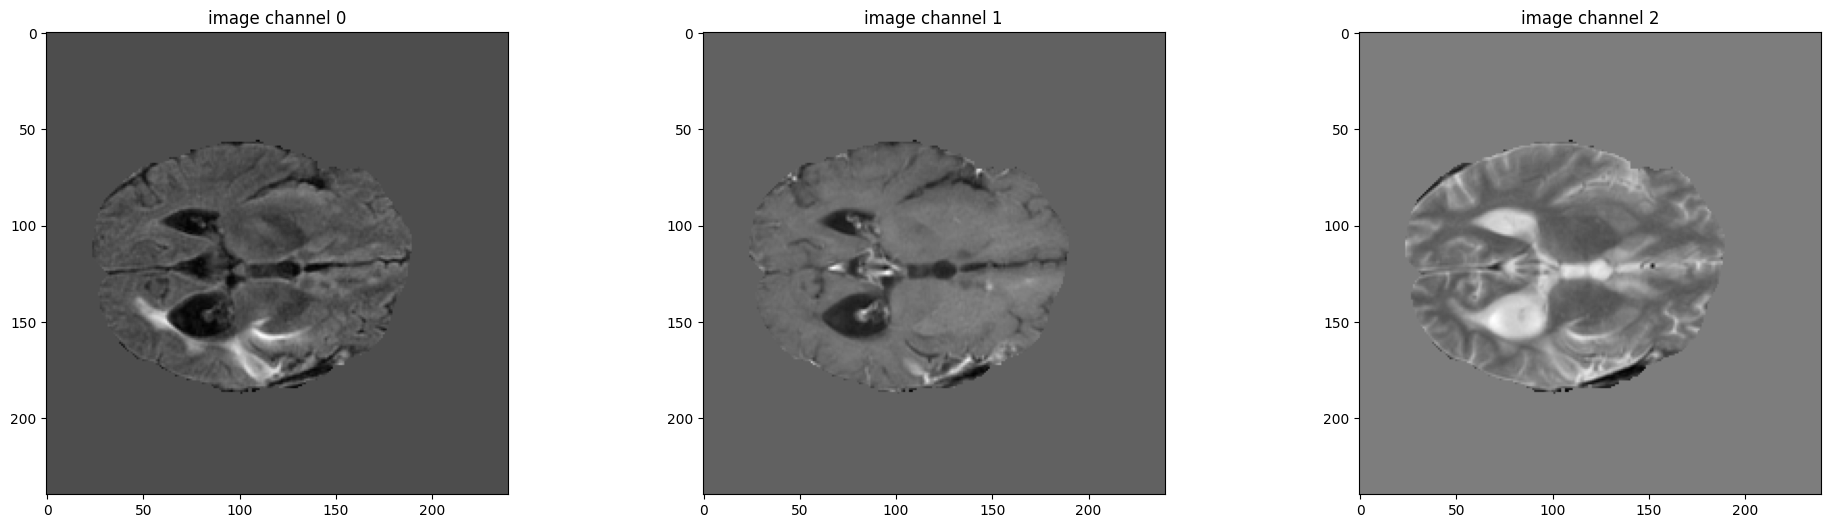

label shape: torch.Size([3, 240, 240, 155])


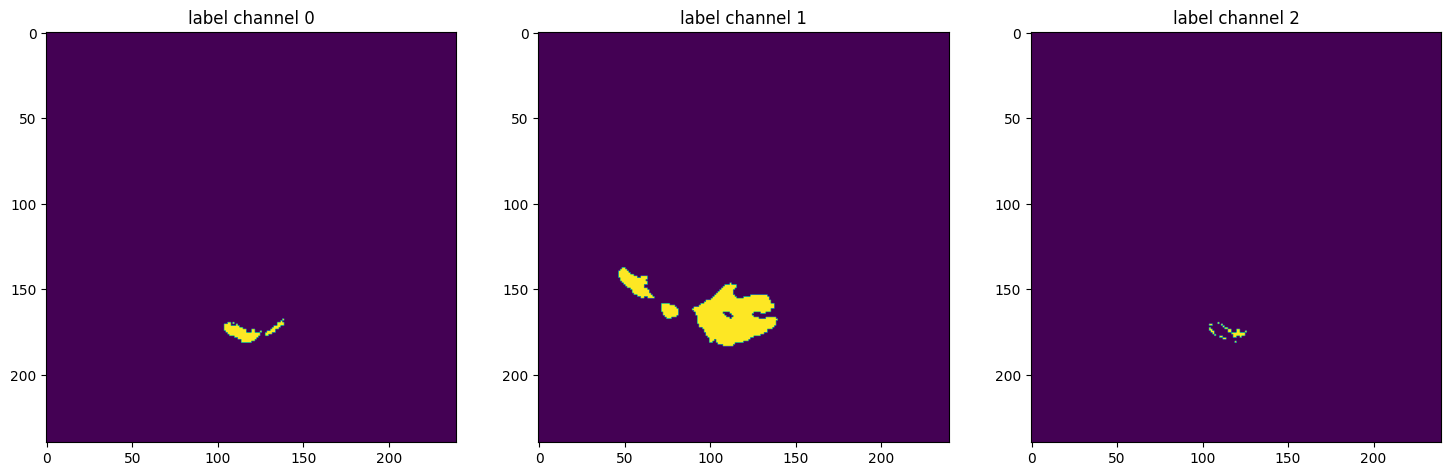

In [9]:
# pick one image from DecathlonDataset to visualize and check the 3 channels
val_data_example = val_ds[77]
print(f"image shape: {val_data_example['image'].shape}")
plt.figure("image", (24, 6))
for i in range(3):
    plt.subplot(1, 3, i + 1)
    plt.title(f"image channel {i}")
    plt.imshow(val_data_example["image"][i, :, :, 60].detach().cpu(), cmap="gray")
plt.show()
# also visualize the 3 channels label corresponding to this image
print(f"label shape: {val_data_example['label'].shape}")
plt.figure("label", (18, 6))
for i in range(3):
    plt.subplot(1, 3, i + 1)
    plt.title(f"label channel {i}")
    plt.imshow(val_data_example["label"][i, :, :, 60].detach().cpu())
plt.show()

## Define 2D network and losses

In [10]:
from transformers import Dinov2Model, Dinov2PreTrainedModel
from transformers.modeling_outputs import SemanticSegmenterOutput

class LinearClassifier(torch.nn.Module):
    def __init__(self, in_channels, num_labels=4):
        super(LinearClassifier, self).__init__()
        self.in_channels = in_channels
        self.classifier = torch.nn.Sequential(
            torch.nn.Conv2d(in_channels, 128, kernel_size=1),
            torch.nn.ReLU(inplace=True),
            torch.nn.Dropout(0.3),
            torch.nn.Conv2d(128, num_labels, kernel_size=1))
        

    def forward(self, embeddings):
        # The embeddings shape is [batch_size, num_patches + 1, hidden_size]
        # We need to remove the CLS token and reshape for the conv layer
        patch_embeddings = embeddings[:, 1:, :]  # Remove CLS token

        # Get batch size from input
        batch_size = embeddings.shape[0]

        # Assuming the patches form a 2D grid (e.g., 32x32 for Dinov2-base)
        # Calculate the grid size from the number of patches
        num_patches = patch_embeddings.shape[1]
        grid_size = int(num_patches ** 0.5)  # Assuming square grid

        # Reshape to [batch_size, grid_size, grid_size, hidden_size]
        patch_embeddings = patch_embeddings.reshape(batch_size, grid_size, grid_size, self.in_channels)

        # Permute to [batch_size, hidden_size, grid_size, grid_size] for Conv2d
        patch_embeddings = patch_embeddings.permute(0, 3, 1, 2)

        return self.classifier(patch_embeddings)


class Dinov2ForSemanticSegmentation(Dinov2PreTrainedModel):
    def __init__(self, config):
        super().__init__(config)
        self.dinov2 = Dinov2Model(config)
        self.classifier = LinearClassifier(config.hidden_size, config.num_labels)

    def forward(self, pixel_values, output_hidden_states=False, output_attentions=False, labels=None):
        # Get embeddings from frozen features
        outputs = self.dinov2(pixel_values,
                            output_hidden_states=output_hidden_states,
                            output_attentions=output_attentions)

        # Get the patch embeddings (excluding CLS token)
        patch_embeddings = outputs.last_hidden_state[:, 1:, :]

        # Convert to logits and upsample to the size of the pixel values
        logits = self.classifier(outputs.last_hidden_state)

        # Upsample to match input spatial dimensions
        logits = torch.nn.functional.interpolate(logits, size=pixel_values.shape[2:], mode="bilinear", align_corners=False)

        loss = None
        if labels is not None:
            loss_fct = monai.losses.DiceLoss(sigmoid=True, to_onehot_y=False)
            loss = loss_fct(logits, labels)

        return SemanticSegmenterOutput(
            loss=loss,
            logits=logits,
            hidden_states=outputs.hidden_states,
            attentions=outputs.attentions,
        )

In [11]:
label_dict = {0: "TC (Tumor core)", 1: "WT (Whole tumor)", 2: "ET (Enhancing tumor)"}

In [12]:
model = Dinov2ForSemanticSegmentation.from_pretrained("facebook/dinov2-base", id2label=label_dict, num_labels=len(label_dict))

config.json:   0%|          | 0.00/548 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Some weights of Dinov2ForSemanticSegmentation were not initialized from the model checkpoint at facebook/dinov2-base and are newly initialized: ['classifier.classifier.0.bias', 'classifier.classifier.0.weight', 'classifier.classifier.3.bias', 'classifier.classifier.3.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [13]:
for name, param in model.named_parameters():
  if name.startswith("dinov2"):
    param.requires_grad = False

In [14]:
batch = next(iter(train_loader))
print(batch["image"].shape)
print(batch["label"].shape)

torch.Size([64, 3, 48, 48])
torch.Size([64, 3, 48, 48])


## The training loop

In [15]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = Dinov2ForSemanticSegmentation.from_pretrained("facebook/dinov2-base", id2label=label_dict, num_labels=len(label_dict)).to(device)
for name, param in model.named_parameters():
  if name.startswith("dinov2"):
    param.requires_grad = False
# loss_function = monai.losses.DiceLoss(sigmoid=True, to_onehot_y=False)
optimizer = torch.optim.Adam(model.parameters(), 5e-3)

Some weights of Dinov2ForSemanticSegmentation were not initialized from the model checkpoint at facebook/dinov2-base and are newly initialized: ['classifier.classifier.0.bias', 'classifier.classifier.0.weight', 'classifier.classifier.3.bias', 'classifier.classifier.3.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [16]:
epoch_loss_values = []
num_epochs = 5
for epoch in range(num_epochs):
    print("-" * 10)
    print(f"epoch {epoch + 1}/{num_epochs}")
    model.train()
    epoch_loss, step = 0, 0
    for batch_data in train_loader:
        step += 1
        inputs, labels = batch_data["image"].to(device), batch_data["label"].to(device)
        optimizer.zero_grad()
        outputs = model(pixel_values=inputs, labels=labels)
        loss = outputs.loss
        # loss = loss_function(outputs.logits, labels)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
        if step % 200 == 0:
            print(f"{step}, train_loss: {loss.item():.4f}")
    epoch_loss /= step
    epoch_loss_values.append(epoch_loss)
    print(f"epoch {epoch + 1} average loss: {epoch_loss:.4f}")
print("train completed")

----------
epoch 1/5
200, train_loss: 0.3125
400, train_loss: 0.4531
600, train_loss: 0.0312
800, train_loss: 0.7292
epoch 1 average loss: 0.4022
----------
epoch 2/5
200, train_loss: 0.3125
400, train_loss: 0.4531
600, train_loss: 0.0312
800, train_loss: 0.7292
epoch 2 average loss: 0.3816
----------
epoch 3/5
200, train_loss: 0.3125
400, train_loss: 0.4531
600, train_loss: 0.0312
800, train_loss: 0.7292
epoch 3 average loss: 0.3816
----------
epoch 4/5
200, train_loss: 0.3125
400, train_loss: 0.4531
600, train_loss: 0.0312
800, train_loss: 0.7292
epoch 4 average loss: 0.3816
----------
epoch 5/5
200, train_loss: 0.3125
400, train_loss: 0.4531
600, train_loss: 0.0312
800, train_loss: 0.7292
epoch 5 average loss: 0.3816
train completed


In [17]:
import os
save_path = os.path.join(root_dir, "model_trained")
model.save_pretrained(save_path)
model = Dinov2ForSemanticSegmentation.from_pretrained(save_path).to(device)

Dimensioni batch di esempio - immagini: torch.Size([1, 3, 240, 240, 155]), labels: torch.Size([1, 3, 240, 240, 155])
val_probs min/max: 0.0 1.5677160025278243e-29
val_preds_discrete shape: torch.Size([1, 3, 240, 240, 155])
val_gt shape: torch.Size([1, 3, 240, 240, 155])
val_preds_discrete unique values: metatensor([0.], device='cuda:0')
val_gt unique values: metatensor([0., 1.], device='cuda:0')
Batch 0 - Dice: 0.0000


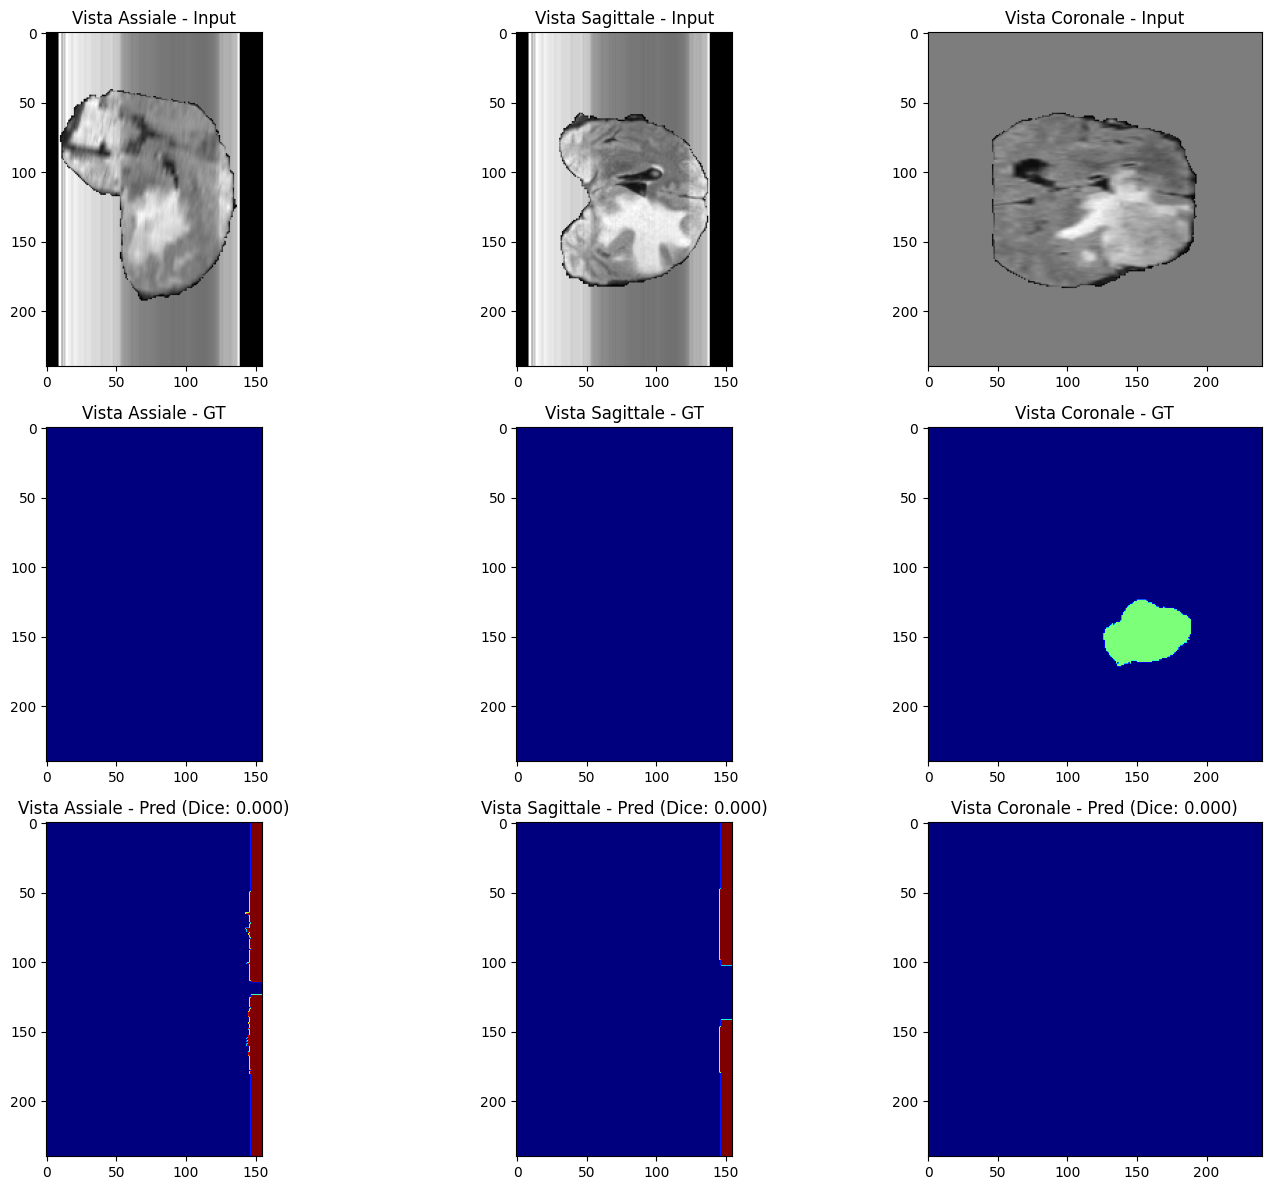

val_probs min/max: 0.0 0.0
val_preds_discrete shape: torch.Size([1, 3, 240, 240, 155])
val_gt shape: torch.Size([1, 3, 240, 240, 155])
val_preds_discrete unique values: metatensor([0.], device='cuda:0')
val_gt unique values: metatensor([0., 1.], device='cuda:0')
Batch 1 - Dice: 0.0000
val_probs min/max: 0.0 1.492076266645923e-24
val_preds_discrete shape: torch.Size([1, 3, 240, 240, 155])
val_gt shape: torch.Size([1, 3, 240, 240, 155])
val_preds_discrete unique values: metatensor([0.], device='cuda:0')
val_gt unique values: metatensor([0., 1.], device='cuda:0')
Batch 2 - Dice: 0.0000
val_probs min/max: 0.0 5.441203482724657e-30
val_preds_discrete shape: torch.Size([1, 3, 240, 240, 155])
val_gt shape: torch.Size([1, 3, 240, 240, 155])
val_preds_discrete unique values: metatensor([0.], device='cuda:0')
val_gt unique values: metatensor([0., 1.], device='cuda:0')
Batch 3 - Dice: 0.0000
val_probs min/max: 0.0 0.0
val_preds_discrete shape: torch.Size([1, 3, 240, 240, 155])
val_gt shape: torch

In [18]:
from monai.transforms import AsDiscrete

# Configurazione del DataLoader
data_loader = DataLoader(val_ds, num_workers=1, pin_memory=torch.cuda.is_available())
dice_metric = DiceMetric(include_background=True, reduction="mean_batch", get_not_nans=False)
model.eval()


#post_pred = AsDiscrete(argmax=True)
post_pred = AsDiscrete(threshold=0.5)
# post_label = AsDiscrete()

# Controllo delle dimensioni del primo batch per debug
sample_batch = next(iter(data_loader))
print(f"Dimensioni batch di esempio - immagini: {sample_batch['image'].shape}, labels: {sample_batch['label'].shape}")

# Configurazione dello SliceInferer (una sola volta)
roi_size = (48, 48)  # Dimensione delle ROI per l'inferenza
sw_batch_size = 64    # Sliding window batch size
spatial_dim = 1       # Dimensione lungo cui affettare (tipicamente 1 per assiale)

slice_inferer = SliceInferer(
    roi_size=roi_size,
    sw_batch_size=sw_batch_size,
    spatial_dim=spatial_dim,
    device=torch.device("cuda" if torch.cuda.is_available() else "cpu"),  # Adaptive device
    padding_mode="replicate",
)

with torch.no_grad():
    for batch_idx, val_data in enumerate(data_loader):
        val_images = val_data["image"].to(device)
        val_gt = val_data["label"].to(device)
        
        # Inferenza slice-by-slice
        val_output = slice_inferer(val_images, model)
        val_output_tensor = val_output["logits"] if "logits" in val_output else val_output["out"]
        # val_probs = torch.softmax(val_output_tensor, dim=1)
        val_probs = torch.sigmoid(val_output_tensor)
        print("val_probs min/max:", val_probs.min().item(), val_probs.max().item())

        
        val_preds_discrete = post_pred(val_probs)
        # val_gt_discrete = post_label(val_gt)

        print("val_preds_discrete shape:", val_preds_discrete.shape)
        print("val_gt shape:", val_gt.shape)
        print("val_preds_discrete unique values:", val_preds_discrete.unique())
        print("val_gt unique values:", val_gt.unique())
        
        # Calcolo metriche
        dice_metric(y_pred=val_preds_discrete, y=val_gt)
        current_dice = dice_metric.get_buffer()[-1].mean().item()  # Media sulle classi
        print(f"Batch {batch_idx} - Dice: {current_dice:.4f}")
        
        # Visualizzazione solo per il primo elemento del primo batch
        if batch_idx == 0:
            # Prendiamo la slice centrale per ogni dimensione
            slice_pos = [s//2 for s in val_images.shape[2:]]
            
            fig, axes = plt.subplots(3, 3, figsize=(15, 12))
            
            # Assumiamo canale 0 come input, modificare se necessario
            input_slice = val_images[0, 0].cpu().numpy()  # Primo elemento del batch
            
            # Predizione (classe con massima probabilità)
            val_pred = torch.argmax(val_probs, dim=1)[0].cpu().numpy()
            
            # Ground truth (convertito se one-hot)
            gt_slice = val_gt[0, 0].cpu().numpy() if val_gt.shape[1] > 1 else val_gt[0].cpu().numpy()
            
            # Visualizzazione delle tre viste ortogonali
            for i, (slice_idx, title) in enumerate(zip(
                slice_pos, 
                ["Vista Assiale", "Vista Sagittale", "Vista Coronale"]
            )):
                # Input
                axes[0,i].imshow(np.take(input_slice, slice_idx, axis=i), cmap='gray')
                axes[0,i].set_title(f"{title} - Input")
                
                # Ground Truth
                axes[1,i].imshow(np.take(gt_slice, slice_idx, axis=i), cmap='jet', vmin=0, vmax=val_probs.shape[1]-1)
                axes[1,i].set_title(f"{title} - GT")
                
                # Predizione
                axes[2,i].imshow(np.take(val_pred, slice_idx, axis=i), cmap='jet', vmin=0, vmax=val_probs.shape[1]-1)
                axes[2,i].set_title(f"{title} - Pred (Dice: {current_dice:.3f})")
            
            plt.tight_layout()
            plt.show()

    # Risultato finale con deviazione standard
    dice_scores = dice_metric.get_buffer()
    avg_dice = dice_metric.aggregate().mean().item()
    std_dice = torch.std(dice_scores).item() if len(dice_scores) > 1 else 0.0
    print(f"\nRisultato Finale - Dice: {avg_dice:.4f} ± {std_dice:.4f}")




    